In [1]:
import os
import sys
#sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import diffusionsim.training_utils as tru
import torch
import torch.nn as nn
from typing import Optional
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
from pprint import pprint
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

In [2]:
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
torch.set_grad_enabled(False); print("grad enabled: ", torch.is_grad_enabled())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

grad enabled:  False


'cuda'

In [3]:
#exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"

In [4]:
num_models = 4

In [5]:
exp_ids = ["DistLossTesting"] * num_models
run_ids = [f"trial1{l}" for l in "abcd"]
list(zip(exp_ids, run_ids))

[('DistLossTesting', 'trial1a'),
 ('DistLossTesting', 'trial1b'),
 ('DistLossTesting', 'trial1c'),
 ('DistLossTesting', 'trial1d')]

In [7]:
log_dicts = []
models = dict(keys=run_ids)
for i in range(num_models):
    log_dict_path = os.path.join(exp_dir, exp_ids[i], f"{run_ids[i]}.json")
    with open(log_dict_path, 'r') as f:
        log_dict = json.load(f)
    mconfig = tru.ModelConfig(**log_dict['model_config'])
    log_dicts.append(log_dict)
    models[run_ids[i]] = tru.load_model_from_ckpt(
        os.path.join("checkpoints", f"{run_ids[i]}-ckpt.pt"), mconfig, exp_ids[i], exp_dir, baseline=True
    ).to(device)

In [8]:
data_vars = log_dicts[0]['model_config']['data_vars']

In [18]:
log_dicts[0]['training_config'].keys()

dict_keys(['exp_id', 'run_id', 'num_epochs', 'phases', 'distributed_training', 'optimizer', 'betas', 'lr_scheduler', 'learning_rate', 'loss_weights', 'clip_gradients', 'max_T_sample', 'save_best_epoch', 'batch_logging_interval', 'batch_checkpoint_interval', 'log_gradients', 'push_to_hub', 'diffusion_loss_noise_level', 'num_gaussians', 'num_distloss_samples', 'distloss_bs', 'distloss_var_ind'])

In [19]:
dconfig = tru.DataConfig(**log_dicts[0]['data_config'])
dconfig.dataset_type = "climsim"
dconfig.source = "gcsfs"

In [21]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='gcsfs',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=24576,
                                               shuffle=True,
                                               num_workers=4,
                                               prefetch_factor=3,
                                               persistent_workers=True,
                                               multiprocessing_context='forkserver',
                                               pin_memory=True),
           xarr_subsamples=[36, 210240, 144],
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True,
           shuffle_indices=False)


## Loading data and predictions

In [33]:
#dconfig.train_test_split = [0.01, 0.002]
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)
dl, edl = dataloaders

In [45]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    edl.dataset.X.load()
    edl.dataset.Y.load()

[########################################] | 100% Completed | 2.75 sms


In [48]:
x, y = torch.tensor(edl.dataset.X.data), torch.tensor(edl.dataset.Y.data)

x.shape, y.shape

(torch.Size([161280, 124]), torch.Size([161280, 128]))

In [ ]:
dutils = 

In [49]:
type(edl.dataset)

diffusionsim.mydatasets.ClimsimDataset

## Utils

In [33]:

def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

## Comparing MSE models to DistLoss models

In [5]:
targeted_vars = [68, 60, 73, 82]
num_gaussians = [3, 2, 3, 2]

In [4]:
#exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DistLossTesting"
run_id = "trial1"
base_dir = os.path.join(exp_dir, exp_id)
log_dicts = {}
mconfigs = []
distloss_models = {}
base_dir

'/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments/DistLossTesting'

In [ ]:
lettering = 'abcdefghijklmnopqrstuvwxyz'
for i in range(4):
    fpath = os.path.join(base_dir, f"trial1{lettering[i]}.json")
    print(fpath)
    with open(fpath, 'r') as f:
        log_dict = json.load(f)
    model_path = os.path.join(base_dir, "checkpoints", )
    mconfig = tru.ModelConfig(**log_dict['model_config'])
    mconfigs.append(mconfig)
    distloss_models[targeted_vars[i]] = tru.load_model_from_ckpt(f"checkpoints/{run_id}{lettering[i]}-ckpt.pt", mconfig, exp_id, exp_dir, baseline=True)
    log_dicts[targeted_vars[i]] = log_dict


In [ ]:
mse_base_dir = os.path.join(exp_dir, "JointTraining")
with open(mse_base_dir + "/trial0.json", 'r') as f:
    mse_log_dict = json.load(f)
mse_model = tru.load_model_from_ckpt("checkpoints/trial0_just_mse.pt", mse_log_dict['model_config'], "JointTraining", exp_dir, baseline=True).to(device)


/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:206: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

In [10]:
dconfig = tru.my_dconfig(data_vars='v1', in_notebook=True, dataset_type='climsim', batch_size=64)
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.01, 0.002]
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)

In [11]:
dl, edl = dataloaders
batch = dl.dataset[8]

{"event": "get-batch start", "time": 1746556633.1034007, "pid": 201, "batch_idx": 8}
{"event": "get-batch end", "time": 1746556639.235854, "pid": 201, "batch_idx": 8, "duration": 6.1324462890625}


In [12]:
import dask
from dask.diagnostics import ProgressBar
with ProgressBar():
    edl.dataset.X.load()
    edl.dataset.Y.load()

[########################################] | 100% Completed | 2.53 sms
[########################################] | 100% Completed | 2.76 sms


In [13]:
batch = edl.dataset[5]
x, y = batch[0].to(device), batch[1].to(device)

{"event": "get-batch start", "time": 1746556658.3384597, "pid": 201, "batch_idx": 5}
{"event": "get-batch end", "time": 1746556658.3559685, "pid": 201, "batch_idx": 5, "duration": 0.017505407333374023}


In [18]:
predictions = {}
targeted_vars = [0]
for var in targeted_vars:
    predictions[var] = distloss_models[var](x)


#predictions['mse'] = mse_model(x)

In [19]:
predictions


{0: tensor([[-0.1425, -0.2213, -0.1863,  ...,  0.5426,  0.1314,  0.2032],
         [-0.2247, -0.4214, -0.5047,  ...,  0.4082,  0.1149,  0.2778],
         [ 0.3785,  0.3956,  0.5076,  ...,  0.5731,  0.3020,  0.1897],
         ...,
         [ 0.0179,  0.0796, -0.0405,  ..., -0.5127, -0.2213,  0.0099],
         [ 0.0601,  0.0377, -0.2934,  ..., -0.6877, -0.2482, -0.1266],
         [ 0.0324,  0.0728, -0.1072,  ..., -0.5223, -0.2859, -0.1227]],
        device='cuda:0')}

In [110]:
targeted_vars = [68, 60, 73, 82]
num_gaussians = [3, 2, 3, 2]

VAR_IND = 68
num_gaussians = 3

In [56]:
predictions[68].shape

torch.Size([24576, 128])

In [46]:
y_sel = y[:, VAR_IND].detach().cpu().numpy()
gmm = GaussianMixture(n_components=num_gaussians)
gmm.fit(y_sel[:, None])

x = 

GaussianMixture(n_components=3)

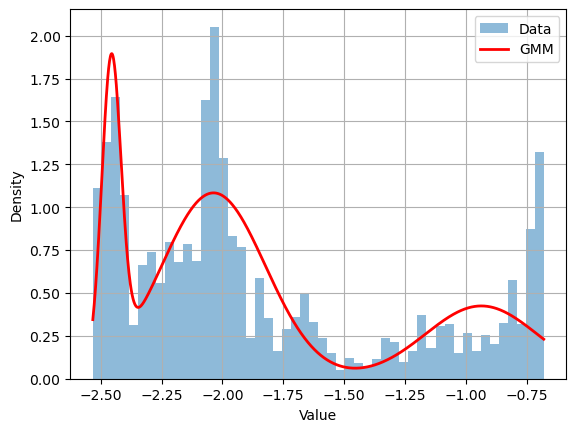

In [48]:
densities = plot_gmm_distribution(gmm, y_sel)

In [57]:
mlo = edl.dataset.mlo

In [112]:
from ipywidgets import interact, widgets
from matplotlib import pyplot as plt

def discrepancy_viewer(predictions, cmap='viridis'):
    # Define interactive plot function
    viewable_keys = [68, 73, 82, 'mse', 'true']
    var_inds = [68, 73, 82]
    num_gaussians = [3, 3, 2]

    def plot_image(var_index, index):
        VAR_IND = var_inds[var_index]
        y_sel = y[:, VAR_IND].detach().cpu().numpy()
        gmm = GaussianMixture(n_components=num_gaussians[var_index])
        gmm.fit(y_sel[:, None])
        if(viewable_keys[index] == 'true'):
            pred = y_sel
        else:
            pred = predictions[viewable_keys[index]][:, VAR_IND].detach().cpu().numpy()

        x = torch.linspace(y_sel.min(), y_sel.max(), 1000)
        densities = torch.exp(torch.tensor(gmm.score_samples(x.reshape(-1,1))))
        plt.plot(x, densities, label='gmm density learned from y')
        plt.hist(pred, density=True, label=f'{viewable_keys[index]} predictions', bins=50, alpha=0.75)
        #plt.hist(y_sel, density=True, label='histogram of y', bins=50, alpha=0.5)
        plt.title(f"Predictions of {mlo[VAR_IND].item()} ({VAR_IND}) from model {viewable_keys[index]}")
        plt.legend()
        plt.show()

    # Create interactive widgets
    variable_slider = widgets.IntSlider(value=0, min=0, max=len(var_inds)-1, step=1, description='Variable:')
    model_slider = widgets.IntSlider(value=0, min=0, max=len(viewable_keys)-1, step=1, description='Model:')
    interact(plot_image, var_index=variable_slider, index=model_slider)
    

In [113]:
discrepancy_viewer(predictions)

interactive(children=(IntSlider(value=0, description='Variable:', max=2), IntSlider(value=0, description='Mode…

In [124]:
log_dicts[68]['mse_loss']

[4.527252197265625,
 4.550696849822998,
 4.119123458862305,
 3.8886404037475586,
 3.911012649536133,
 3.357983350753784,
 3.0401313304901123,
 2.549130916595459,
 1.8338078260421753,
 1.4429019689559937]

In [83]:
log_dicts[68]['losses'].keys(), log_dicts[68].keys()

(dict_keys(['train', 'eval', 'mse', 'total', 'distribution']),
 dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_loss', 'eval_loss', 'mse_loss', 'total_loss', 'distribution_loss']))

In [84]:
log_dicts[68]['losses']['distribution']

[608.4487290577996,
 91.63995440111174,
 25.008587602670577,
 3.952058943332647,
 1.5230343460759823,
 1.3789262776476883,
 1.089513006941102,
 0.7624602114499852,
 2.0283779477402644,
 2.5872405428406804]

In [99]:
log_dicts.keys()

dict_keys([68, 60, 73, 82])

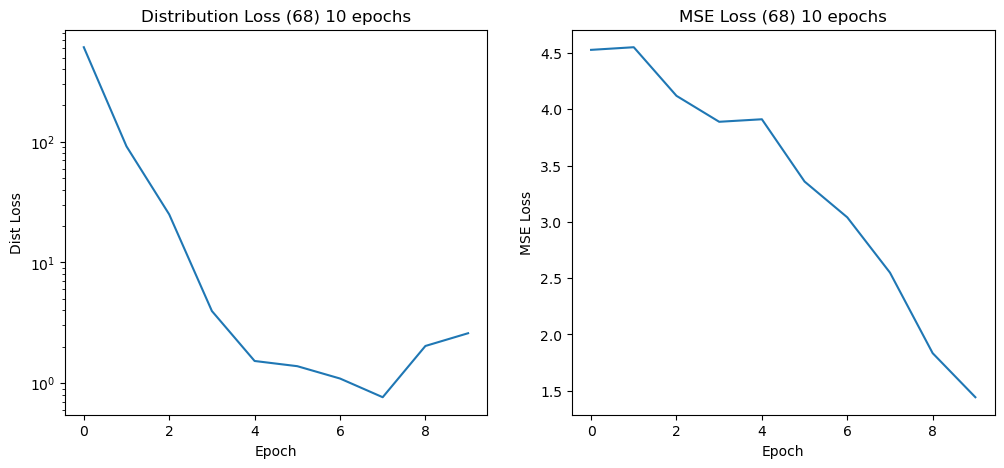

In [115]:
key = 68
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # Create 2 subplots side by side
ax1.plot(log_dicts[key]['distribution_loss'], label='distribution')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Dist Loss')
ax1.set_yscale('log')
ax1.set_title(f'Distribution Loss ({key}) 10 epochs')
ax2.plot(log_dicts[key]['mse_loss'], label='mse')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.set_title(f'MSE Loss ({key}) 10 epochs')

plt.show()


In [118]:
log_dicts.keys()

dict_keys([68, 60, 73, 82])

In [120]:
losses = []
key = 68
loss_fn = torch.nn.MSELoss()
for step, (x, y) in enumerate(edl):
    x = x.to(device)
    y = y.to(device)
    y_hat = distloss_models[key](x)
    mse_loss = loss_fn(y_hat, y)
    losses.append(mse_loss.item())
    

{"event": "get-batch start", "time": 1744122558.546282, "pid": 2574277, "batch_idx": 2}
{"event": "get-batch end", "time": 1744122558.5724804, "pid": 2574277, "batch_idx": 2, "duration": 0.02618694305419922}
{"event": "get-batch start", "time": 1744122558.7202022, "pid": 2574277, "batch_idx": 5}
{"event": "get-batch end", "time": 1744122558.73105, "pid": 2574277, "batch_idx": 5, "duration": 0.010845661163330078}
{"event": "get-batch start", "time": 1744122558.7360487, "pid": 2574277, "batch_idx": 0}
{"event": "get-batch end", "time": 1744122558.7495153, "pid": 2574277, "batch_idx": 0, "duration": 0.013464689254760742}
{"event": "get-batch start", "time": 1744122558.7539594, "pid": 2574277, "batch_idx": 4}
{"event": "get-batch end", "time": 1744122558.7666261, "pid": 2574277, "batch_idx": 4, "duration": 0.012664794921875}
{"event": "get-batch start", "time": 1744122558.7704258, "pid": 2574277, "batch_idx": 1}
{"event": "get-batch end", "time": 1744122558.7810912, "pid": 2574277, "batch_

In [122]:
np.mean(losses)

np.float64(1.8108816345532734)

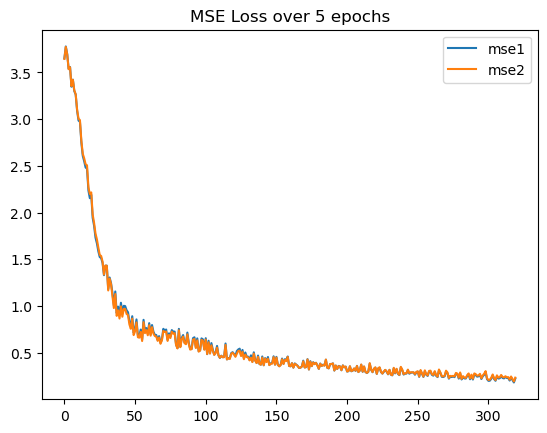

In [23]:
plt.plot(np.array(mse_log_dict['mse_only_losses']['mse']), label='mse1')
plt.plot(np.array(mse_log_dict['dist_losses']['mse']), label='mse2')
plt.title('MSE Loss over 5 epochs')
plt.legend()
plt.show()

In [24]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}

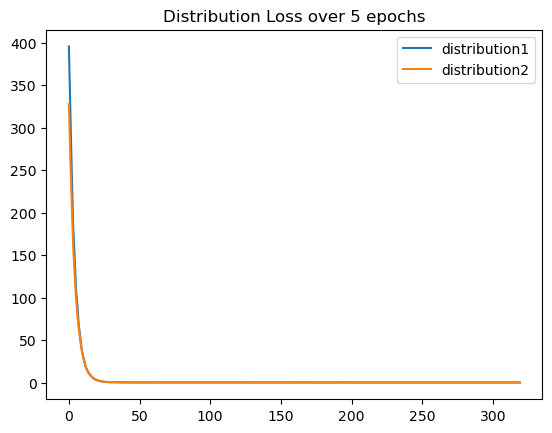

In [27]:
plt.plot(np.array(mse_log_dict['mse_only_losses']['distribution']), label='distribution1')
plt.plot(np.array(mse_log_dict['dist_losses']['distribution']), label='distribution2')
plt.title('Distribution Loss over 5 epochs')
plt.legend()
plt.show()

In [9]:
(train_ds, test_ds), (train_indices, test_indices) = data.load_dataset(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [14]:
x, y = train_ds[0]
x.shape, y.shape


(torch.Size([12288, 124]), torch.Size([12288, 128]))

In [46]:
model_mse = tru.build_baseline_model(mconfig, from_ckpt=True, ckpt_path=os.path.join(base_dir, f"trial0_just_mse.pt"))
model_dist = tru.build_baseline_model(mconfig, from_ckpt=True, ckpt_path=os.path.join(base_dir, f"trial0_dist_loss.pt"))

model_mse.eval().to(device)
model_dist.eval().to(device)

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

### Plotting Utils

In [51]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x)

In [34]:
def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

def plot_gmm_distribution(gmm, data, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(gmm, x, training=False, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

# Trying to use data utils
- replicate https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html
- https://github.com/leap-stc/ClimSim/blob/main/preprocessing/create_npy_data_splits.ipynb

Inspired by [Climsim guide](https://leap-stc.github.io/ClimSim/evaluation/main_figure_generation.html)

In [6]:
from diffusionsim import climsim_utils as cut
from diffusionsim import mydatasets as data

In [7]:
dconfig = tru.my_dconfig("v1", in_notebook=True, dataset_type="climsim", 
                         batch_size=16, use_tendencies=True)
dconfig.source = "gcsfs"

In [8]:
dutils = cut.setup_data_utils(dconfig.climsim_type, dconfig.source, dconfig.data_vars, 
                            dconfig.use_tendencies, data_dir=dconfig.data_dir)

In [9]:
dsi, dso, dutils  = cut.load_raw_dataset(dconfig, return_dutils=True)

In [10]:
self = data.ClimsimDataset(
    dsi.unify_chunks(), dso.unify_chunks(), dutils, dconfig, log=True
)

In [62]:
dutils.use_tendencies

True

In [46]:
dutils.input_mean.load()

<xarray.Dataset> Size: 5kB
Dimensions:           (lev: 60)
Dimensions without coordinates: lev
Data variables: (12/27)
    cam_in_ALDIF      float64 8B 0.5598
    cam_in_ALDIR      float64 8B 0.5762
    cam_in_ASDIF      float64 8B 0.5485
    cam_in_ASDIR      float64 8B 0.5653
    cam_in_ICEFRAC    float64 8B 0.03713
    cam_in_LANDFRAC   float64 8B 0.2994
    ...                ...
    state_q0001       (lev) float64 480B 1.776e-06 1.779e-06 ... 0.009731
    state_q0002       (lev) float64 480B 3.228e-34 3.197e-34 ... 3.563e-06
    state_q0003       (lev) float64 480B 5.748e-12 6.073e-12 ... 1.679e-06
    state_t           (lev) float64 480B 215.6 227.9 237.3 ... 286.7 287.6 288.4
    state_u           (lev) float64 480B 8.6 10.57 12.13 ... 0.09664 -0.04455
    state_v           (lev) float64 480B -1.201 -0.521 -0.2416 ... 0.1936 0.1666

In [43]:
dutils.output_scale.load()

<xarray.Dataset> Size: 3kB
Dimensions:         (lev: 60)
Dimensions without coordinates: lev
Data variables: (12/14)
    ptend_t         (lev) float64 480B 1.005e+03 1.005e+03 ... 1.005e+03
    ptend_q0001     (lev) float64 480B 2.835e+06 2.835e+06 ... 2.835e+06
    ptend_q0002     (lev) float64 480B 5.669e+06 5.669e+06 ... 5.669e+06
    ptend_q0003     (lev) float64 480B 2.835e+06 2.835e+06 ... 2.835e+06
    ptend_u         (lev) float64 480B 250.0 250.0 250.0 ... 250.0 250.0 250.0
    ptend_v         (lev) float64 480B 500.0 500.0 500.0 ... 500.0 500.0 500.0
    ...              ...
    cam_out_PRECSC  float64 8B 1.244e+07
    cam_out_PRECC   float64 8B 1.313e+06
    cam_out_SOLS    float64 8B 0.005
    cam_out_SOLL    float64 8B 0.0046
    cam_out_SOLSD   float64 8B 0.0061
    cam_out_SOLLD   float64 8B 0.0095

In [13]:

from dask.diagnostics import ProgressBar
with ProgressBar():
    dl.dataset.X.load()
    dl.dataset.Y.load()
    edl.dataset.X.load()
    edl.dataset.Y.load()

[########################################] | 100% Completed | 4.06 sms
[########################################] | 100% Completed | 3.74 sms
[########################################] | 100% Completed | 2.14 sms
[########################################] | 100% Completed | 1.92 sms


In [14]:
edl.dataset.X.data.shape

(161280, 124)

In [15]:
batch = next(iter(edl))

{"event": "get-batch start", "time": 1746558540.0125782, "pid": 2339, "batch_idx": 5}
{"event": "get-batch end", "time": 1746558540.040914, "pid": 2339, "batch_idx": 5, "duration": 0.028330326080322266}


In [16]:
x_test, y_test = batch[0].to(device), batch[1].to(device)

In [17]:
x_test.mean(), x_test.std(), x_test.shape

(tensor(-0.3615, device='cuda:0'),
 tensor(2.1694, device='cuda:0'),
 torch.Size([24576, 124]))

In [18]:
pred = model(x_test)

In [19]:
#x_test = edl.dataset.X.data
#y_test = edl.dataset.Y.data

#x_test_norm = (x_test - edl.dataset.xm.numpy()) / edl.dataset.xs.numpy()
#y_test_norm = (y_test - edl.dataset.ym.numpy()) / edl.dataset.ys.numpy()

#y_mse_test = model_mse(torch.tensor(x_test_norm, dtype=torch.float32).to(device)).detach().cpu().numpy()
#y_dist_test = model_dist(torch.tensor(x_test_norm, dtype=torch.float32).to(device)).detach().cpu().numpy()

In [20]:
loss = torch.nn.MSELoss()

loss(y_test, pred)

tensor(0.2256, device='cuda:0')

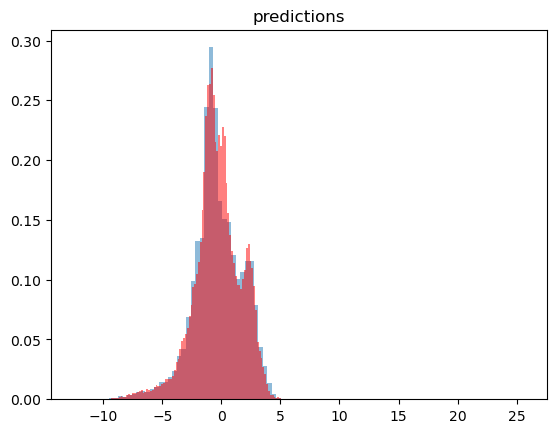

In [27]:
hist(y_test.flatten(), "y_test", bins=100, alpha=0.5, density=True)
hist(pred.flatten(), "predictions", bins=100, alpha=0.5, color='red', density=True)
plt.show()

In [31]:
dutils.setup_metrics()
dutils.metrics_dict

{'MAE': <bound method data_utils.calc_MAE of <diffusionsim.climsim_utils.data_utils object at 0x7b556ae34110>>,
 'RMSE': <bound method data_utils.calc_RMSE of <diffusionsim.climsim_utils.data_utils object at 0x7b556ae34110>>,
 'R2': <bound method data_utils.calc_R2 of <diffusionsim.climsim_utils.data_utils object at 0x7b556ae34110>>,
 'CRPS': <bound method data_utils.calc_CRPS of <diffusionsim.climsim_utils.data_utils object at 0x7b556ae34110>>,
 'bias': <bound method data_utils.calc_bias of <diffusionsim.climsim_utils.data_utils object at 0x7b556ae34110>>}

In [32]:
dutils.metrics_names = list(dutils.metrics_dict.keys())
dutils.metrics_names

['MAE', 'RMSE', 'R2', 'CRPS', 'bias']

In [39]:
dutils.target_vars

['state_t',
 'state_q0001',
 'cam_out_NETSW',
 'cam_out_FLWDS',
 'cam_out_PRECSC',
 'cam_out_PRECC',
 'cam_out_SOLS',
 'cam_out_SOLL',
 'cam_out_SOLSD',
 'cam_out_SOLLD']

In [41]:
dutils.num_latlon

384

In [40]:
dutils.input_scoring

In [94]:
mu_real, sigma_real = np.mean(y_test_norm), np.std(y_test_norm)
mu_mse, sigma_mse = np.mean(y_mse_test), np.std(y_mse_test)
mu_dist, sigma_dist = np.mean(y_dist_test), np.std(y_dist_test)



In [95]:
mu_real, mu_mse, mu_dist

(np.float64(-0.35196832216689283),
 np.float32(-0.36175743),
 np.float32(-0.36169025))

In [96]:
sigma_real, sigma_mse, sigma_dist

(np.float64(2.084488076556322), np.float32(2.016912), np.float32(2.0150366))

In [65]:
dutils.input_scoring = x_test_norm
dutils.target_scoring = y_test_norm
# set pressure weights
dutils.set_pressure_grid(data_split = 'scoring')

# load model predictions
dutils.model_names = ['mse_model', 'dist_model']
predictions = {
    'mse_model' : y_mse_test, 
    'dist_model' : y_dist_test
}

dutils.preds_scoring = predictions

1. Undo output scaling

2. Weight vertical levels by dp/g
3. Weight horizontal area of each grid cell by a[x]/mean(a[x])
4. Convert units to a common energy unit

In [61]:
y_test

array([[2.11955523e+02, 2.22814364e+02, 2.29187058e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.09319429e+02, 2.21327028e+02, 2.28610102e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.18145683e+02, 2.29463219e+02, 2.36486204e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [2.23846468e+02, 2.31604638e+02, 2.35934344e+02, ...,
        4.35842573e-04, 4.60220406e+01, 3.35470072e+01],
       [2.26222575e+02, 2.39913993e+02, 2.41833158e+02, ...,
        1.83709516e+02, 1.26466997e+02, 7.37017160e+01],
       [2.23984718e+02, 2.46728271e+02, 2.47862872e+02, ...,
        6.94026290e+00, 6.12777178e+01, 4.75462976e+01]])

In [54]:
dutils.reweight_target(data_split = 'scoring')
dutils.reweight_preds(data_split = 'scoring')


In [56]:
dutils.target_vars

['state_t',
 'state_q0001',
 'cam_out_NETSW',
 'cam_out_FLWDS',
 'cam_out_PRECSC',
 'cam_out_PRECC',
 'cam_out_SOLS',
 'cam_out_SOLL',
 'cam_out_SOLSD',
 'cam_out_SOLLD']

In [23]:
#dutils.preds_weighted_scoring

In [55]:
dutils.metrics_names = ['MAE', 'RMSE', 'R2']
dutils.create_metrics_df(data_split = 'scoring')

KeyError: 'state_t'